<a href="https://colab.research.google.com/github/JustinTime-05/Exercise-Classifier/blob/main/APS360_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Home Exercise Classifier From Video**

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Upload the UCF101 Dataset

In [ ]:
import os # for file and directory management

dataset_path = "/content/drive/MyDrive/UCF101/UCF-101"

# I will only be using a subset of videos from the UCF101 dataset (exercise videos)
classes = ["BodyWeightSquats", "JumpingJack", "Lunges", "PushUps", "WallPushups"]
num_classes = len(classes)

video_files = [] # will contain pairs of file path of the video and labels
class_counts = [0] * len(classes) # keep track of the number of videos in each class

# loop through all classes
for class_name in classes:
  class_path = os.path.join(dataset_path, class_name) # path to the class subfolder
  for file in os.listdir(class_path): # loop through the files
    if file.endswith(".avi"): # all video files are .avi, this is just a safeguard
      video_files.append((os.path.join(class_path, file), class_name)) # add the file path and class label
      class_counts[classes.index(class_name)] += 1 # increment the count for that class

print("Total videos:", len(video_files))
# print number of videos per class
print("\nVideos per Class:")
for i in range(len(classes)):
  print(f"{classes[i]}: {class_counts[i]}")

Total videos: 594

Videos per Class:
BodyWeightSquats: 112
JumpingJack: 123
Lunges: 127
PushUps: 102
WallPushups: 130


## Break the Videos into their Frames (20 frames per video)

In [ ]:
import cv2 # used for frame splitting
import numpy as np

# helper function that takes a video and breaks it into frames
def extract_frames(video_path, label, num_frames=32):
  video_name = os.path.basename(video_path) # get the video name
  # create the output directory where the frames will go
  frames_dir = "/content/Frames"
  output_dir = os.path.join(frames_dir, label, video_name)
  os.makedirs(output_dir, exist_ok=True) # create the directory if it doesn't exist

  # open the video using OpenCV
  video = cv2.VideoCapture(video_path)
  total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT)) # get the total number of frames in the video
  # safety check in case the video failed to open
  if total_frames == 0:
    print("Failed to open video:", video_name)
    return

  # we won't save every frame in the video since there would be quite a lot
  # evenly choose which frames to sample
  frame_indicies = np.linspace(0, total_frames - 1, num_frames, dtype=int)
  frame_indicies = set(frame_indicies) # convert to set for faster lookup
  cur_frame = 0 # keep track of current frame while we loop through the video frames
  saved_frames = 0 # record the number of frames we saved for the video

  # iterate through the video frames until there are no frames left
  while True:
    success, frame = video.read() # read the next frame

    # exit once we reach the end of the video
    if not success:
      break

    # check if the current frame should be saved
    if cur_frame in frame_indicies:
      frame_num = saved_frames
      frame_filename = f"{video_name}_frame_{frame_num:02}.jpg" # set the name for the file
      frame_path = os.path.join(output_dir, frame_filename) # get the file path
      cv2.imwrite(frame_path, frame) # save the frame
      saved_frames += 1 # increment the number of saved frames

    cur_frame += 1 # increment the current frame

  # if we saved fewer than num_frames, repeat the last frame
  while saved_frames < num_frames:
    last_frame_path = os.path.join(output_dir, f"{video_name}_frame_{saved_frames-1:02}.jpg") # previous frame
    new_frame_path = os.path.join(output_dir, f"{video_name}_frame_{saved_frames:02}.jpg") # next frame

    frame = cv2.imread(last_frame_path)
    cv2.imwrite(new_frame_path, frame) # set next frame to be same as previous frame

    saved_frames += 1

  video.release() # release the video

  return saved_frames # return the number of saved frames

In [ ]:
from tqdm import tqdm # for progress bar
# break the videos into frames
total_frames = 0 # keep track of the total number of frames saved
for video_path, label in tqdm(video_files, desc="Converting videos to frames"):
  total_frames += extract_frames(video_path, label, num_frames=20)

print(f"\nSaved {total_frames} total frames")

Converting videos to frames: 100%|██████████| 594/594 [03:10<00:00,  3.12it/s]


Saved 11880 total frames


## Split the data into Train/Validation/Test

In [ ]:
import os
import random
from collections import defaultdict
# the UCF101 dataset allocates 75% of data for training and 25% for testing/validation
# it offers 3 different ways of splitting the data between training and testing
# define a function that provides the train/val/test data for one of those 3 splits
# returns train/val/test lists of folders containing video frames
def get_train_val_test_folders(train_txt, test_txt):
  # folder containing the text files
  data_split_path = "/content/drive/MyDrive/UCF101/UCF101TrainTestSplits-RecognitionTask/ucfTrainTestlist"

  # gather the train videos
  train_videos = []
  file_path = os.path.join(data_split_path, train_txt) # get the file path
  file = open(file_path, "r") # open the file
  # iterate through the lines in the file
  for line in file:
    line = line.strip() # remove the newline character
    video_path = line.split(" ")[0] # each line contains "video_path class_id"
    class_name = video_path.split("/")[0] # video_path contains "class_name/video_name"
    # ensure the video is one of the exercise videos
    if class_name in classes:
      train_videos.append(video_path)

  # gather the test videos
  test_videos = []
  file_path = os.path.join(data_split_path, test_txt) # get the file path
  file = open(file_path, "r") # open the file
  # iterate through the lines in the file
  for line in file:
    line = line.strip() # remove the newline character
    video_path = line.split(" ")[0] # each line contains "video_path class_id"
    class_name = video_path.split("/")[0] # video_path contains "class_name/video_name"
    # ensure the video is one of the exercise videos
    if class_name in classes:
      test_videos.append(video_path)

  # get the folders of frames for the train videos
  train_folders = []
  for video_path in train_videos:
    class_name, video_name = video_path.split("/")
    frame_folder_path = os.path.join("/content/Frames", class_name, video_name)
    train_folders.append(frame_folder_path)

  # get the folders of frames for the test videos
  test_folders = []
  for video_path in test_videos:
    class_name, video_name = video_path.split("/")
    frame_folder_path = os.path.join("/content/Frames", class_name, video_name)
    test_folders.append(frame_folder_path)

  # split half of the test data for validation
  # but ensure the sets of data include unique people
  # group videos by person group (labelled as gXX in the dataset)
  group_dict = defaultdict(list)

  for folder in test_folders:
    video_name = os.path.basename(folder) # looks like v_Class_g08_c02
    group_id = video_name.split("_")[2] # g08

    group_dict[group_id].append(folder)

  # shuffle the groups
  random.seed(1)
  groups = list(group_dict.keys())
  random.shuffle(groups)

  # split groups into val/test
  num_groups = len(groups)
  val_groups = groups[:num_groups//2]
  test_groups = groups[num_groups//2:] # this ordering gives test more data

  # assign folders based on group
  val_folders = []
  test_split_folders = []

  for group in val_groups:
    val_folders.extend(group_dict[group])

  for group in test_groups:
    test_split_folders.extend(group_dict[group])

  test_folders = test_split_folders

  print("Total Number of Training Videos:", len(train_folders))
  print("Total Number of Validation Videos:", len(val_folders))
  print("Total Number of Testing Videos:", len(test_folders))

  return train_folders, val_folders, test_folders

In [ ]:
# this function takes a list of video folders and returns a list of pairs (list of frame's file paths, label of corresponding video)
def get_data_from_folders(video_folders, num_frames=32):
  data = []
  # loop through the video folders
  for video_folder in video_folders:
    # get the class name
    class_name = video_folder.split("/")[-2] # /content/Frames/class_name/video_name
    # convert class name to numerical label
    label = classes.index(class_name)
    # get the frame files corresponding to the video
    frame_files = sorted(os.listdir(video_folder)) # ensure the frames are in the right order
    frame_files = frame_files[:num_frames] # ensure we have the right number of frames

    # extract the frame paths and add it to the list
    frame_paths = []
    for frame in frame_files:
      frame_paths.append(os.path.join(video_folder, frame))

    # add the frame_path-label pair to the data that the model will use
    data.append((frame_paths, label))

  return data

Total Number of Training Videos: 425
Total Number of Validation Videos: 77
Total Number of Testing Videos: 92
Dimensions of each Frame: 320x240


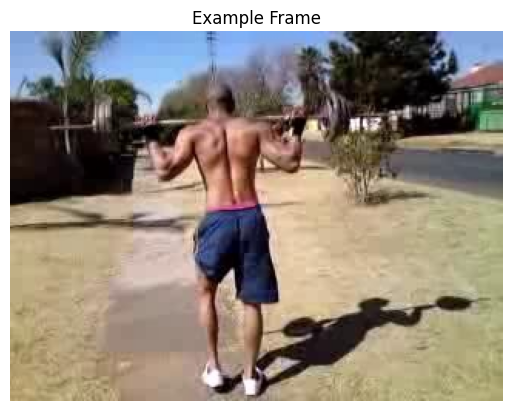

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
# get the data split for the 1st set of train and test videos
train_video_folders, val_video_folders, test_video_folders = get_train_val_test_folders("trainlist01.txt", "testlist01.txt")
train_data = get_data_from_folders(train_video_folders, num_frames=20)
val_data = get_data_from_folders(val_video_folders, num_frames=20)
test_data = get_data_from_folders(test_video_folders, num_frames=20)
# shuffle the data
random.seed(1)
random.shuffle(train_data)
random.shuffle(val_data)
random.shuffle(test_data)
# figure out the dimensions of each frame
frame = Image.open(train_data[0][0][0]) # pick any frame
print(f"Dimensions of each Frame: {frame.size[0]}x{frame.size[1]}")
# display an example frame
plt.imshow(frame)
plt.axis("off")
plt.title("Example Frame")
plt.show()
frame.show()

In [ ]:
# imports
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt # for plotting
import torch.optim as optim # for gradient descent

torch.manual_seed(1) # set the random seed for consistency

## Baseline Model: 2D CNN Classifying By First Frame
This model basically works like an image classifier. For every video, only the first of 20 frames is passed through the CNN and a prediction is made based on the features of only the first frame.

In [ ]:
# define the CNN architecture
class BaselineModel(nn.Module):
  def __init__(self, num_classes):
    super(BaselineModel, self).__init__()
    self.cnn = nn.Sequential(
        nn.Conv2d(3, 16, 3),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(16, 32, 3),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(32, 64, 3),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
        )
    self.fc = nn.Sequential(
        nn.Linear(64 * 28 * 38, 128), # original dimensions of image are H=240, W=320
        nn.ReLU(),
        nn.Linear(128, num_classes)
        )

  def forward(self, x):
    x = self.cnn(x)
    x = x.view(-1, 64 * 28 * 38)
    x = self.fc(x)
    return x

## Train the Baseline Model

In [ ]:
import torch
def baseline_train(model, train_data, val_data, batch_size=64, learning_rate=0.001, num_epochs=20):
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  # record training/validation stats for plotting
  iterations, epochs = [], []
  train_losses, val_losses = [], []
  train_accuracy, val_accuracy = [], []
  i = 0 # current iteration

  for epoch in range(num_epochs):
    # training loop
    model.train()
    epoch_correct = epoch_total = epoch_loss = 0
    correct = total = 0

    for b in range(0, len(train_data), batch_size): # loop through all batches
      batch = train_data[b:b+batch_size] # get the batch section
      # gather the videos (1st frame of each video) and labels for the model
      videos = []
      labels = []

      for frame_paths, label in batch:
        # extract the actual frame image
        frame_img = Image.open(frame_paths[0]) # frame image shape: (W, H)
        # convert to tensor and permute the dimensions to be (C, H, W)
        frame_img = torch.from_numpy(np.array(frame_img)).permute(2, 0, 1).float() / 255.0
        # add the frame and label to the list
        videos.append(frame_img)
        labels.append(label)
      # now group the videos and labels from the whole batch
      videos = torch.stack(videos) # shape: (batch_size, C, W, H)
      labels = torch.tensor(labels) # shape: (batch_size)

      # enable GPU
      if torch.cuda.is_available():
        videos = videos.cuda()
        labels = labels.cuda()

      output = model(videos) # forward pass
      loss = criterion(output, labels) # compute loss
      loss.backward() # backward pass
      optimizer.step() # update parameters
      optimizer.zero_grad() # reset gradients

      # record train loss
      iterations.append(i)
      train_losses.append(loss.item())
      # record train accuracy
      prediction = output.max(1, keepdim=True)[1] # pick the indices with the largest prediction to be the actual predictions
      correct = prediction.eq(labels.view_as(prediction)).sum().item() # increment for every image where prediction is same as ground truth
      total = videos.shape[0] # increment by size of that batch
      train_accuracy.append(correct / total) # training accuracy
      i+=1
      # update epoch stats
      epoch_correct += correct
      epoch_total += total
      epoch_loss += loss.item() * videos.shape[0]

    # validation loop
    model.eval()
    val_loss = correct = total = 0

    for b in range(0, len(val_data), batch_size): # loop through all batches
      batch = val_data[b:b+batch_size] # get the batch section
      # gather the videos (1st frame of each video) and labels for the model
      videos = []
      labels = []

      for frame_paths, label in batch:
        # extract the actual frame image
        frame_img = Image.open(frame_paths[0]) # frame image shape: (W, H)
        # convert to tensor and permute the dimensions to be (C, H, W)
        frame_img = torch.from_numpy(np.array(frame_img)).permute(2, 0, 1).float() / 255.0
        # add the frame and label to the list
        videos.append(frame_img)
        labels.append(label)
      # now group the videos and labels from the whole batch
      videos = torch.stack(videos) # shape: (batch_size, C, W, H)
      labels = torch.tensor(labels) # shape: (batch_size)

      # enable GPU
      if torch.cuda.is_available():
        videos = videos.cuda()
        labels = labels.cuda()

      output = model(videos) # forward pass
      loss = criterion(output, labels) # compute loss

      # increment val loss
      val_loss += loss.item() * videos.shape[0]
      # increment val accuracy
      prediction = output.max(1, keepdim=True)[1] # pick the indices with the largest prediction to be the actual predictions
      correct += prediction.eq(labels.view_as(prediction)).sum().item() # increment for every image where prediction is same as ground truth
      total += videos.shape[0] # increment by size of that batch

    # record validation loss and accuracy
    val_losses.append(float(val_loss) / total)
    val_accuracy.append(correct / total)
    epochs.append(epoch)

    # print some summary info every epoch
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training Accuracy (epoch): {epoch_correct/epoch_total:.4f}")
    print(f"Training Loss (epoch): {epoch_loss/epoch_total:.4f}")
    print(f"Validation Accuracy: {correct/total:.4f}")
    print(f"Validation Loss: {val_loss/total:.4f}")
    print("-"*40)

  # training plots
  plt.figure()
  plt.title("Training Loss (per batch)")
  plt.plot(iterations, train_losses, color="orange")
  plt.xlabel("Iteration")
  plt.ylabel("Loss")
  plt.show()

  plt.figure()
  plt.title("Training Accuracy (per batch)")
  plt.plot(iterations, train_accuracy, color="orange")
  plt.xlabel("Iteration")
  plt.ylabel("Accuracy")
  plt.show()

  # validation plots
  plt.figure()
  plt.title("Validation Loss (per epoch)")
  plt.plot(epochs, val_losses)
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.show()

  plt.figure()
  plt.title("Validation Accuracy (per epoch)")
  plt.plot(epochs, val_accuracy)
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.show()

  print("Final Training Accuracy:", train_accuracy[-1])
  print("Final Validation Accuracy:", val_accuracy[-1])

Using GPU
Epoch 1/20
Training Accuracy (epoch): 0.2259
Training Loss (epoch): 1.6043
Validation Accuracy: 0.2338
Validation Loss: 1.5791
----------------------------------------
Epoch 2/20
Training Accuracy (epoch): 0.3106
Training Loss (epoch): 1.5445
Validation Accuracy: 0.3766
Validation Loss: 1.5327
----------------------------------------
Epoch 3/20
Training Accuracy (epoch): 0.4612
Training Loss (epoch): 1.4585
Validation Accuracy: 0.3636
Validation Loss: 1.4671
----------------------------------------
Epoch 4/20
Training Accuracy (epoch): 0.6094
Training Loss (epoch): 1.3552
Validation Accuracy: 0.5065
Validation Loss: 1.3961
----------------------------------------
Epoch 5/20
Training Accuracy (epoch): 0.6259
Training Loss (epoch): 1.2428
Validation Accuracy: 0.4026
Validation Loss: 1.3373
----------------------------------------
Epoch 6/20
Training Accuracy (epoch): 0.6329
Training Loss (epoch): 1.1342
Validation Accuracy: 0.3636
Validation Loss: 1.3026
-----------------------

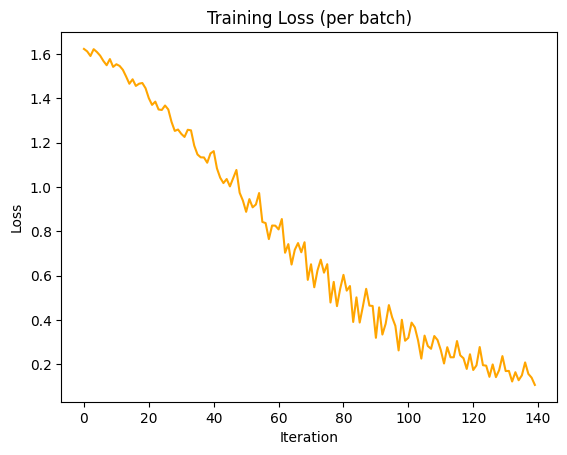

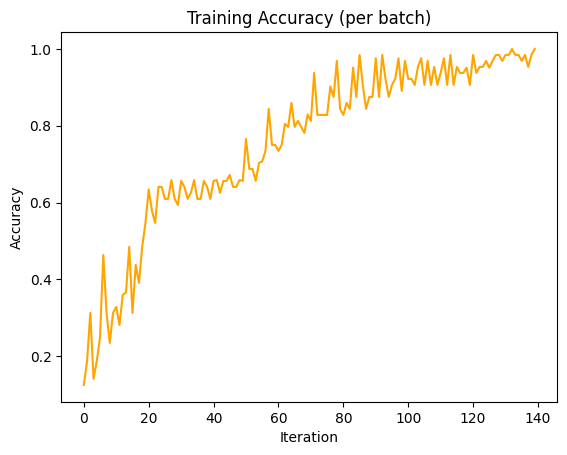

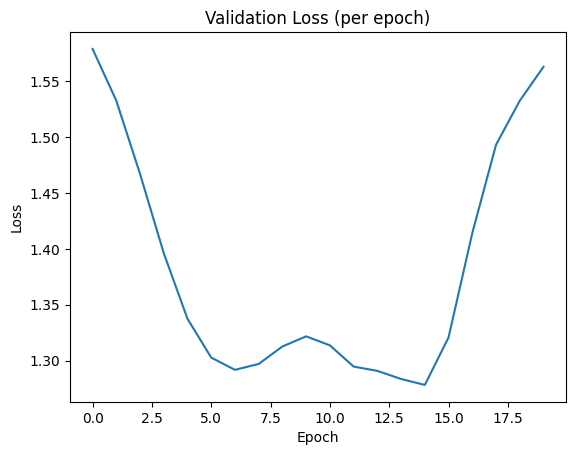

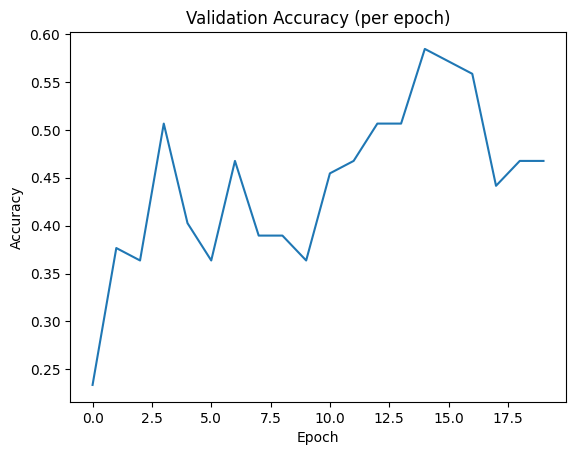

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.4675324675324675


In [ ]:
# enable GPU
if torch.cuda.is_available():
  model = BaselineModel(num_classes=5).cuda()
  print("Using GPU")
else:
  model = BaselineModel(num_classes=5)
  print("Using CPU")
# train the primary model
baseline_train(model, train_data, val_data, batch_size=64, learning_rate=0.0001, num_epochs=20)

## Test the Baseline Model

In [ ]:
# test the baseline model
model.eval()
# used to record accuracy per class
num_classes = len(classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes
correct = total = 0
batch_size = 8
for b in range(0, len(test_data), batch_size): # loop through all batches
  batch = test_data[b:b+batch_size] # get the batch section
  # gather the videos (1st frame of each video) and labels for the model
  videos = []
  labels = []

  for frame_paths, label in batch:
    # extract the actual frame image
    frame_img = Image.open(frame_paths[0]) # frame image shape: (W, H)
    # convert to tensor and permute the dimensions to be (C, H, W)
    frame_img = torch.from_numpy(np.array(frame_img)).permute(2, 0, 1).float() / 255.0
    # add the frame and label to the list
    videos.append(frame_img)
    labels.append(label)
  # now group the videos and labels from the whole batch
  videos = torch.stack(videos) # shape: (batch_size, C, W, H)
  labels = torch.tensor(labels) # shape: (batch_size)

  # enable GPU
  if torch.cuda.is_available():
    videos = videos.cuda()
    labels = labels.cuda()

  output = model(videos) # forward pass
  prediction = output.max(1, keepdim=True)[1] # pick the indices with the largest prediction to be the actual predictions
  correct += prediction.eq(labels.view_as(prediction)).sum().item() # increment for every image where prediction is same as ground truth
  total += videos.shape[0] # increment by size of that batch
  # record accuracy per class
  for i in range(len(labels)):
    label = labels[i].item()
    class_correct[label] += prediction[i].eq(labels[i].view_as(prediction[i])).item()
    class_total[label] += 1

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")
# print accuracy per class
print("\nAccuracy per Class:")
for i in range(num_classes):
  class_accuracy = class_correct[i] / class_total[i]
  print(f"{classes[i]}: {class_accuracy:.4f}")

Test Accuracy: 0.5109

Accuracy per Class:
BodyWeightSquats: 0.4118
JumpingJack: 0.8571
Lunges: 0.6842
PushUps: 0.2941
WallPushups: 0.2222


## Primary Model: 2D CNN Averaging Frame Features
**Note:** This model was trained on an input of 32 frames per video.  
The model passes the 32 frames associated with a particular video through a 2D CNN to extract features from each frame. Those features are then averaged over the 32 frames in the video, then passed through a fully connected layer to make a prediction on one of the 5 classes.

In [ ]:
# define the CNN architecture
class PrimaryModel(nn.Module):
  def __init__(self, num_classes):
    super(PrimaryModel, self).__init__()
    self.cnn = nn.Sequential(
        nn.Conv2d(3, 16, 3),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(16, 32, 3),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(32, 64, 3),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
        )
    self.fc = nn.Sequential(
        nn.Linear(64 * 28 * 38, 128), # original dimensions of image are H=240, W=320
        nn.ReLU(),
        nn.Linear(128, num_classes)
        )

  def forward(self, x):
    # x will take all frames for a single video at once
    batch_size, num_frames, c, h, w = x.size()
    # cnn expects (batch_size, c, h, w), so merge the batch size and frames
    x = x.view(batch_size * num_frames, c, h, w)
    # run through the cnn
    x = self.cnn(x)
    # flatten and separate batch and individual frame
    x = x.view(batch_size, num_frames, 64 * 28 * 38)
    # average over the frames to make a prediction
    x = x.mean(dim=1)
    # pass through linear layer and make prediction
    x = self.fc(x)
    return x

## Train the Primary Model

In [ ]:
import torch
def primary_train(model, train_data, val_data, batch_size=64, learning_rate=0.001, num_epochs=20, num_frames=32):
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  # record training/validation stats for plotting
  iterations, epochs = [], []
  train_losses, val_losses = [], []
  train_accuracy, val_accuracy = [], []
  i = 0 # current iteration

  for epoch in range(num_epochs):
    # training loop
    model.train()
    epoch_correct = epoch_total = epoch_loss = 0
    correct = total = 0

    for b in range(0, len(train_data), batch_size): # loop through all batches
      batch = train_data[b:b+batch_size] # get the batch section
      # gather the videos (collection of frames) and labels for the model
      videos = []
      labels = []

      for frame_paths, label in batch:
        # extract the actual frame images
        frames = []
        for frame in frame_paths:
          frame_img = Image.open(frame) # frame image shape: (W, H)
          # convert to tensor and permute the dimensions to be (C, H, W)
          frame_img = torch.from_numpy(np.array(frame_img)).permute(2, 0, 1).float() / 255.0
          frames.append(frame_img)
        # group the frames corresponding to the video
        frames = torch.stack(frames) # shape: (num_frames, C, W, H)
        videos.append(frames)
        labels.append(label)
      # now group the videos and labels from the whole batch
      videos = torch.stack(videos) # shape: (batch_size, num_frames, C, W, H)
      labels = torch.tensor(labels) # shape: (batch_size)

      # enable GPU
      if torch.cuda.is_available():
        videos = videos.cuda()
        labels = labels.cuda()

      output = model(videos) # forward pass
      loss = criterion(output, labels) # compute loss
      loss.backward() # backward pass
      optimizer.step() # update parameters
      optimizer.zero_grad() # reset gradients

      # record train loss
      iterations.append(i)
      train_losses.append(loss.item())
      # record train accuracy
      prediction = output.max(1, keepdim=True)[1] # pick the indices with the largest prediction to be the actual predictions
      correct = prediction.eq(labels.view_as(prediction)).sum().item() # increment for every image where prediction is same as ground truth
      total = videos.shape[0] # increment by size of that batch
      train_accuracy.append(correct / total) # training accuracy
      i+=1
      # update epoch stats
      epoch_correct += correct
      epoch_total += total
      epoch_loss += loss.item() * videos.shape[0]

    # validation loop
    model.eval()
    val_loss = correct = total = 0

    for b in range(0, len(val_data), batch_size): # loop through all batches
      batch = val_data[b:b+batch_size] # get the batch section
      # gather the videos (collection of frames) and labels for the model
      videos = []
      labels = []

      for frame_paths, label in batch:
        # extract the actual frame images
        frames = []
        for frame in frame_paths:
          frame_img = Image.open(frame) # frame image shape: (W, H)
          # convert to tensor and permute the dimensions to be (C, H, W)
          frame_img = torch.from_numpy(np.array(frame_img)).permute(2, 0, 1).float() / 255.0
          frames.append(frame_img)
        # group the frames corresponding to the video
        frames = torch.stack(frames) # shape: (num_frames, C, W, H)
        videos.append(frames)
        labels.append(label)
      # now group the videos and labels from the whole batch
      videos = torch.stack(videos) # shape: (batch_size, num_frames, C, W, H)
      labels = torch.tensor(labels) # shape: (batch_size)

      # enable GPU
      if torch.cuda.is_available():
        videos = videos.cuda()
        labels = labels.cuda()

      output = model(videos) # forward pass
      loss = criterion(output, labels) # compute loss

      # increment val loss
      val_loss += loss.item() * videos.shape[0]
      # increment val accuracy
      prediction = output.max(1, keepdim=True)[1] # pick the indices with the largest prediction to be the actual predictions
      correct += prediction.eq(labels.view_as(prediction)).sum().item() # increment for every image where prediction is same as ground truth
      total += videos.shape[0] # increment by size of that batch

    # record validation loss and accuracy
    val_losses.append(float(val_loss) / total)
    val_accuracy.append(correct / total)
    epochs.append(epoch)

    # print some summary info every epoch
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training Accuracy (epoch): {epoch_correct/epoch_total:.4f}")
    print(f"Training Loss (epoch): {epoch_loss/epoch_total:.4f}")
    print(f"Validation Accuracy: {correct/total:.4f}")
    print(f"Validation Loss: {val_loss/total:.4f}")
    print("-"*40)

  # training plots
  plt.figure()
  plt.title("Training Loss (per batch)")
  plt.plot(iterations, train_losses, color="orange")
  plt.xlabel("Iteration")
  plt.ylabel("Loss")
  plt.show()

  plt.figure()
  plt.title("Training Accuracy (per batch)")
  plt.plot(iterations, train_accuracy, color="orange")
  plt.xlabel("Iteration")
  plt.ylabel("Accuracy")
  plt.show()

  # validation plots
  plt.figure()
  plt.title("Validation Loss (per epoch)")
  plt.plot(epochs, val_losses)
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.show()

  plt.figure()
  plt.title("Validation Accuracy (per epoch)")
  plt.plot(epochs, val_accuracy)
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.show()

  print("Final Training Accuracy:", train_accuracy[-1])
  print("Final Validation Accuracy:", val_accuracy[-1])

### Training Hyperparameters
For training the primary model, I used a small batch size of 8 since with 32 frames per video, the number of images a model sees per batch significantly increases, so the small batch size combats this. To complement the small batch size, I also used a small learning rate of 0.0005, so that the model doesn't change very drastically after each batch. I used 20 epochs because I noticed some overfitting occuring after around the 20 epoch mark.

Using GPU
Epoch 1/20
Training Accuracy (epoch): 0.3341
Training Loss (epoch): 1.5183
Validation Accuracy: 0.3506
Validation Loss: 1.3524
----------------------------------------
Epoch 2/20
Training Accuracy (epoch): 0.6259
Training Loss (epoch): 1.0305
Validation Accuracy: 0.4286
Validation Loss: 1.2392
----------------------------------------
Epoch 3/20
Training Accuracy (epoch): 0.8024
Training Loss (epoch): 0.6253
Validation Accuracy: 0.4026
Validation Loss: 1.1919
----------------------------------------
Epoch 4/20
Training Accuracy (epoch): 0.9365
Training Loss (epoch): 0.2182
Validation Accuracy: 0.4545
Validation Loss: 1.7178
----------------------------------------
Epoch 5/20
Training Accuracy (epoch): 0.9788
Training Loss (epoch): 0.0892
Validation Accuracy: 0.5065
Validation Loss: 1.8751
----------------------------------------
Epoch 6/20
Training Accuracy (epoch): 0.9812
Training Loss (epoch): 0.0525
Validation Accuracy: 0.4026
Validation Loss: 2.5844
-----------------------

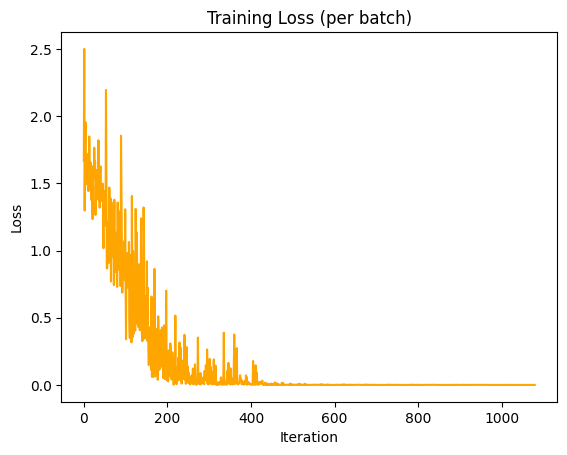

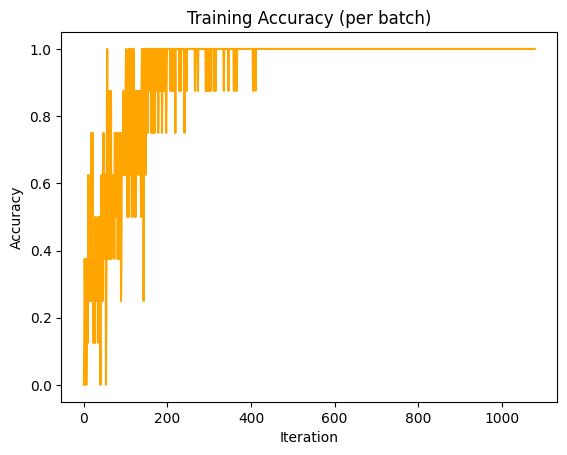

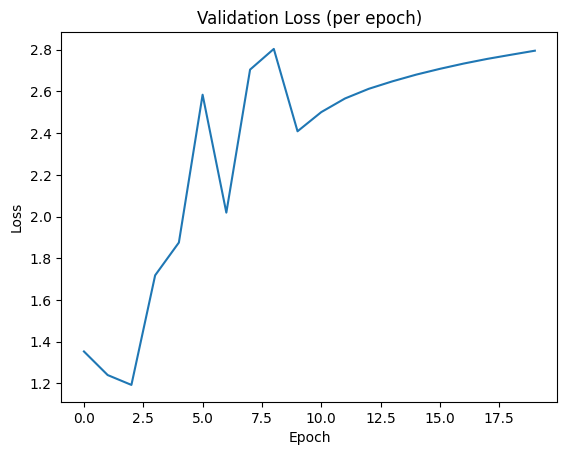

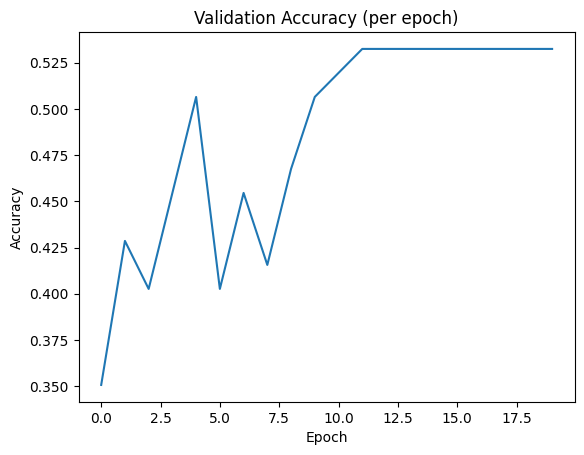

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.5324675324675324


In [ ]:
# enable GPU
if torch.cuda.is_available():
  model = PrimaryModel(num_classes=5).cuda()
  print("Using GPU")
else:
  model = PrimaryModel(num_classes=5)
  print("Using CPU")
# train the primary model
primary_train(model, train_data, val_data, batch_size=8, learning_rate=0.0005, num_epochs=20, num_frames=32)

## Test the Primary Model

In [ ]:
# test the primary model
model.eval()
# used to record accuracy per class
num_classes = len(classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes
correct = total = 0
batch_size = 8
for b in range(0, len(test_data), batch_size): # loop through all batches
  batch = test_data[b:b+batch_size] # get the batch section
  # gather the videos (collection of frames) and labels for the model
  videos = []
  labels = []

  for frame_paths, label in batch:
    # extract the actual frame images
    frames = []
    for frame in frame_paths:
      frame_img = Image.open(frame) # frame image shape: (W, H)
      # convert to tensor and permute the dimensions to be (C, H, W)
      frame_img = torch.from_numpy(np.array(frame_img)).permute(2, 0, 1).float() / 255.0
      frames.append(frame_img)
    # group the frames corresponding to the video
    frames = torch.stack(frames) # shape: (num_frames, C, W, H)
    videos.append(frames)
    labels.append(label)
  # now group the videos and labels from the whole batch
  videos = torch.stack(videos) # shape: (batch_size, num_frames, C, W, H)
  labels = torch.tensor(labels) # shape: (batch_size)

  # enable GPU
  if torch.cuda.is_available():
    videos = videos.cuda()
    labels = labels.cuda()

  output = model(videos) # forward pass
  prediction = output.max(1, keepdim=True)[1] # pick the indices with the largest prediction to be the actual predictions
  correct += prediction.eq(labels.view_as(prediction)).sum().item() # increment for every image where prediction is same as ground truth
  total += videos.shape[0] # increment by size of that batch

  # record accuracy per class
  for i in range(len(labels)):
    label = labels[i].item()
    class_correct[label] += prediction[i].eq(labels[i].view_as(prediction[i])).item()
    class_total[label] += 1

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")
# print accuracy per class
print("\nAccuracy per Class:")
for i in range(num_classes):
  class_accuracy = class_correct[i] / class_total[i]
  print(f"{classes[i]}: {class_accuracy:.4f}")

Test Accuracy: 0.5870

Accuracy per Class:
BodyWeightSquats: 0.4118
JumpingJack: 0.8095
Lunges: 1.0000
PushUps: 0.4118
WallPushups: 0.2222


## Updated Training Functions

In [ ]:
# import the R(2+1)D 18 model
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights
weights = R2Plus1D_18_Weights.DEFAULT
transform = weights.transforms() # transform provided by R(2+1)D 18 model
# this function loads the frames from a given batch
def load_batch(batch, device):
  # gather the videos (collection of frames) and labels for the model
  videos, labels = [], []

  for frame_paths, label in batch:
    # extract the actual frame images
    frames = []
    for frame in frame_paths:
      frame_img = Image.open(frame).resize((320, 240)) # frame image shape: (W, H); resize to 320x240 (size of frames in the UCF101 dataset)
      # convert to tensor and permute the dimensions to be (C, H, W)
      frame_img = torch.from_numpy(np.array(frame_img)).permute(2, 0, 1).float() / 255.0
      frames.append(frame_img)
    # group the frames corresponding to the video
    frames = torch.stack(frames) # shape: (T, C, H, W)
    # preprocess the frames for the model by using the given transform
    frames = transform(frames) # Note: transform will eventually permute shape to (C, T, H, W)

    videos.append(frames)
    labels.append(label)

  # now group the videos and labels from the whole batch
  videos = torch.stack(videos).to(device) # shape: (B, C, T, H, W)
  labels = torch.tensor(labels).to(device) # shape: (B)

  return videos, labels

In [ ]:
# this function gets the model's accuracy over a given dataset
def get_accuracy(model, data, batch_size, device):
  model.eval()
  correct = total = 0

  with torch.no_grad():
    for b in range(0, len(data), batch_size): # loop through all batches
      batch = data[b:b+batch_size] # get the batch section
      videos, labels = load_batch(batch, device) # get the videos and labels from the batch

      # compute accuracy
      output = model(videos) # forward pass
      prediction = output.argmax(dim=1) # pick the indices with the largest prediction to be the actual predictions
      correct += (prediction == labels).sum().item() # increment for every image where prediction is same as ground truth
      total += labels.size(0) # increment by size of that batch

  return correct / total

In [ ]:
# this function calculates specifically validation loss
def get_val_loss(model, val_data, batch_size, criterion, device):
  model.eval()
  total_val_loss = 0
  num_batches = 0
  with torch.no_grad():
    for b in range(0, len(val_data), batch_size): # loop through all batches
      batch = val_data[b:b+batch_size] # get the batch section
      videos, labels = load_batch(batch, device) # get the videos and labels from the batch

      # compute loss
      output = model(videos) # forward pass
      loss = criterion(output, labels)
      total_val_loss += loss.item()
      num_batches += 1

  return total_val_loss / num_batches

In [ ]:
# new and cleaner train function
def train(model, train_data, val_data, batch_size=8, learning_rate=1e-4, num_epochs=5):
    torch.manual_seed(1)
    # enable GPU if possible
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)

    # record train/val loss and accuracy every epoch
    train_loss, val_loss = [], []
    train_acc, val_acc = [], []

    for epoch in range(num_epochs):
      model.train()
      # accumulate train loss over each iteration
      total_train_loss = num_batches = 0
      correct = total = 0 # for recording train accuracy

      for b in range(0, len(train_data), batch_size): # loop through all batches
        batch = train_data[b:b+batch_size] # get the batch section
        videos, labels = load_batch(batch, device) # get the videos and labels from the batch

        # compute loss
        output = model(videos) # forward pass
        loss = criterion(output, labels) # compute loss
        loss.backward() # backward pass
        optimizer.step() # update parameters
        optimizer.zero_grad() # reset gradients
        # accumulate loss
        total_train_loss += loss.item()
        num_batches += 1
        # accumulate accuracy
        prediction = output.argmax(dim=1) # pick the indices with the largest prediction to be the actual predictions
        correct += (prediction == labels).sum().item() # increment for every image where prediction is same as ground truth
        total += labels.size(0) # increment by size of that batch

      # update train/val loss and accuracy
      train_loss.append(total_train_loss / num_batches)
      val_loss.append(get_val_loss(model, val_data, batch_size, criterion, device))
      train_acc.append(correct / total)
      v_acc = get_accuracy(model, val_data, batch_size, device)
      val_acc.append(v_acc)

      # print some stats per epoch
      print(f"Epoch {epoch+1}/{num_epochs}")
      print(f"Train loss: {train_loss[-1]:.4f}")
      print(f"Val loss: {val_loss[-1]:.4f}")
      print(f"Train accuracy: {train_acc[-1]:.4f}")
      print(f"Val accuracy: {val_acc[-1]:.4f}")
      print("-"*40)

    # plots
    plt.figure()
    plt.title("Training and Validation Loss")
    plt.plot(range(1, num_epochs+1), train_loss, label="Training")
    plt.plot(range(1, num_epochs+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.title("Training and Validation Accuracy")
    plt.plot(range(1, num_epochs+1), train_acc, label="Training")
    plt.plot(range(1, num_epochs+1), val_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    print("Final Training Accuracy:", train_acc[-1])
    print("Final Validation Accuracy:", val_acc[-1])

In [ ]:
# this function creates a confusion matrix to help analyze results
def print_confusion_matrix(model, data, batch_size, device, classes):
  model.eval()
  num_classes = len(classes)
  # matrix to store counts, rows = actual, columns = predicted
  confusion = np.zeros((num_classes, num_classes), dtype=int)

  # compute predictions over the full dataset
  with torch.no_grad():
    for b in range(0, len(data), batch_size):
      videos, labels = load_batch(data[b:b+batch_size], device)
      prediction = model(videos).argmax(dim=1)
      for i in range(len(labels)):
        confusion[labels[i].item()][prediction[i].item()] += 1

  # print header row with predicted class names
  col_width = 20
  print()
  print("Actual \\ Predicted".ljust(col_width), end="")
  for c in classes:
    print(c.ljust(col_width), end="")
  print()

  # print each row with actual class name and counts
  for i in range(num_classes):
    print(classes[i].ljust(col_width), end="")
    for j in range(num_classes):
      print(str(confusion[i][j]).ljust(col_width), end="")
    print()

## Secondary Model: 3D CNN

In [ ]:
class CNN3D(nn.Module):
  def __init__(self, num_classes=5):
    super(CNN3D, self).__init__()
    self.conv = nn.Sequential(
        # conv3d shape: (B, C, T, H, W) where T is time/depth or frames for this project
        nn.Conv3d(3, 32, kernel_size=(3,3,3), padding=(1,1,1)), # 1 padding to not lose spatial dimensions each layer
        nn.BatchNorm3d(32), nn.ReLU(), # batch norm and relu for stable values
        nn.MaxPool3d(kernel_size=(1,2,2)), # pool space but not time yet so the model can learn the physical features first

        nn.Conv3d(32, 64, kernel_size=(3,3,3), padding=(1,1,1)),
        nn.BatchNorm3d(64), nn.ReLU(),
        nn.MaxPool3d(kernel_size=(2,2,2)), # now pool time too
        nn.Dropout3d(0.1), # apply 3d dropout to drop an entire channel, but with low probability, to prevent overfitting

        nn.Conv3d(64, 128, kernel_size=(3,3,3), padding=(1,1,1)), # same as above just increasing channels for more detail
        nn.BatchNorm3d(128), nn.ReLU(),
        nn.MaxPool3d(kernel_size=(2,2,2)),
        nn.Dropout3d(0.1),

        nn.Conv3d(128, 256, kernel_size=(3,3,3), padding=(1,1,1)),
        nn.BatchNorm3d(256), nn.ReLU(),
        nn.AdaptiveAvgPool3d((1,3,3)), # collapse to fixed size, arbitrary but not too large for the fc layer
        nn.Dropout(0.3), # regular dropout since we just collapsed
    )
    self.fc = nn.Sequential(
        nn.Linear(256 * 1 * 3 * 3, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

  def forward(self, x):
    B, T, C, H, W = x.size()
    x = x.permute(0, 2, 1, 3, 4) # permute because conv3d expects (B, C, T, H, W)
    x = self.conv(x) # pass through conv3d to get (B, 256, 1, 3, 3)
    x = x.view(B, -1) # collapse for fc (B, 256*9)
    return self.fc(x)

Using device: cuda
New best model saved: (Val accuracy: 0.6104)
----------------------------------------
Epoch 1/10
Train loss: 1.4914
Val loss: 1.1343
Train accuracy: 0.3412
Val accuracy: 0.6104
----------------------------------------
New best model saved: (Val accuracy: 0.7143)
----------------------------------------
Epoch 2/10
Train loss: 1.2110
Val loss: 0.9418
Train accuracy: 0.5294
Val accuracy: 0.7143
----------------------------------------
New best model saved: (Val accuracy: 0.7662)
----------------------------------------
Epoch 3/10
Train loss: 1.0086
Val loss: 0.8158
Train accuracy: 0.6400
Val accuracy: 0.7662
----------------------------------------
Epoch 4/10
Train loss: 0.8380
Val loss: 0.7948
Train accuracy: 0.7012
Val accuracy: 0.6883
----------------------------------------
Epoch 5/10
Train loss: 0.8609
Val loss: 0.6828
Train accuracy: 0.7012
Val accuracy: 0.7532
----------------------------------------
Epoch 6/10
Train loss: 0.8220
Val loss: 0.7091
Train accuracy: 

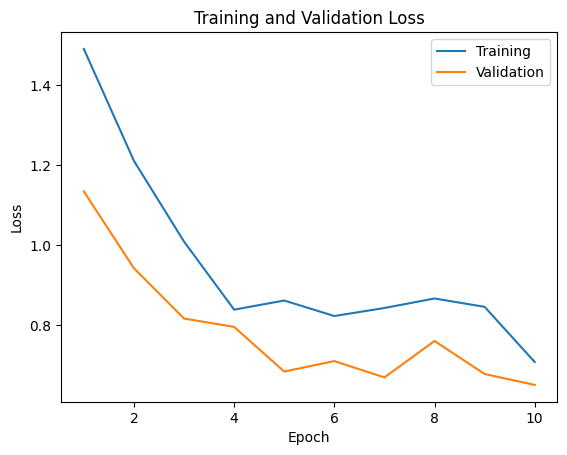

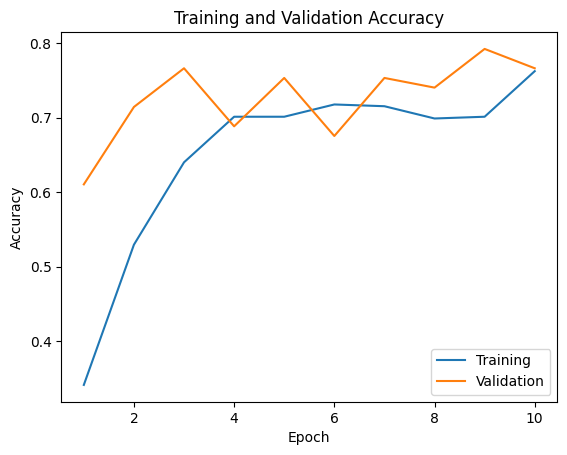

Final Training Accuracy: 0.7623529411764706
Final Validation Accuracy: 0.7662337662337663
Best Validation Accuracy: 0.7922 at Epoch 9


In [ ]:
# train the 3d cnn model
model_cnn3d = CNN3D(num_classes=len(classes))
train(model_cnn3d, train_data, val_data, batch_size=4, learning_rate=1e-4, num_epochs=10)

## Test the Secondary Model

In [ ]:
# test the 3d cnn model
model_cnn3d.eval()
# used to record accuracy per class
num_classes = len(classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes
correct = total = 0
batch_size = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model_cnn3d.to(device)

with torch.no_grad():
  for b in range(0, len(test_data), batch_size): # loop through all batches
    batch = test_data[b:b+batch_size] # get the batch section
    videos, labels = load_batch(batch, device) # get the videos and labels from the batch

    output = model_cnn3d(videos) # forward pass
    prediction = output.argmax(dim=1) # pick the indices with the largest prediction to be the actual predictions
    correct += (prediction == labels).sum().item() # increment for every image where prediction is same as ground truth
    total += labels.size(0) # increment by size of that batch

    # record accuracy per class
    for i in range(len(labels)):
      label = labels[i].item()
      class_correct[label] += (prediction[i] == labels[i]).item()
      class_total[label] += 1

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")
# print accuracy per class
print("\nAccuracy per Class:")
for i in range(num_classes):
  class_accuracy = class_correct[i] / class_total[i]
  print(f"{classes[i]}: {class_accuracy:.4f}")

Using device: cuda
Test Accuracy: 0.7283

Accuracy per Class:
BodyWeightSquats: 0.6471
JumpingJack: 1.0000
Lunges: 1.0000
PushUps: 0.2941
WallPushups: 0.6111


## Final Model: Transfer Learning using R(2+1)D 18

In [ ]:
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights
# define the architecture
class R2Plus1DModel(nn.Module):
  def __init__(self, num_classes=5):
    super().__init__()

    # load pretrained R(2+1)D-18
    r2plus1d = r2plus1d_18(weights=R2Plus1D_18_Weights.DEFAULT)

    # remove final classification layer (fc), keep backbone + avgpool
    self.backbone = nn.Sequential(*list(r2plus1d.children())[:-1])
    # backbone output: (B, 512, 1, 1, 1) after adaptive avgpool

    self.dropout = nn.Dropout(0.5)
    self.fc = nn.Sequential(
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes)
    )

  def forward(self, x):
    # Note: we applied transformed earlier so shape is (B, C, T, H, W), no need to permute
    B, C, T, H, W = x.size()
    x = self.backbone(x) # pass through (B, 512, 1, 1, 1)
    x = x.view(B, 512)
    # apply dropout and pass through fc
    x = self.dropout(x)
    return self.fc(x)

## Train the Final Model

Downloading: "https://download.pytorch.org/models/r2plus1d_18-91a641e6.pth" to /root/.cache/torch/hub/checkpoints/r2plus1d_18-91a641e6.pth


100%|██████████| 120M/120M [00:00<00:00, 193MB/s]


Using device: cuda
Epoch 1/10
Train loss: 1.3010
Val loss: 0.7871
Train accuracy: 0.5388
Val accuracy: 0.9481
----------------------------------------
Epoch 2/10
Train loss: 0.6035
Val loss: 0.4026
Train accuracy: 0.9176
Val accuracy: 0.9351
----------------------------------------
Epoch 3/10
Train loss: 0.2521
Val loss: 0.2493
Train accuracy: 0.9765
Val accuracy: 0.9610
----------------------------------------
Epoch 4/10
Train loss: 0.1294
Val loss: 0.2064
Train accuracy: 0.9929
Val accuracy: 0.9351
----------------------------------------
Epoch 5/10
Train loss: 0.0722
Val loss: 0.2386
Train accuracy: 0.9976
Val accuracy: 0.9351
----------------------------------------
Epoch 6/10
Train loss: 0.0456
Val loss: 0.3767
Train accuracy: 1.0000
Val accuracy: 0.8701
----------------------------------------
Epoch 7/10
Train loss: 0.0357
Val loss: 0.1852
Train accuracy: 1.0000
Val accuracy: 0.9351
----------------------------------------
Epoch 8/10
Train loss: 0.0272
Val loss: 0.2409
Train accu

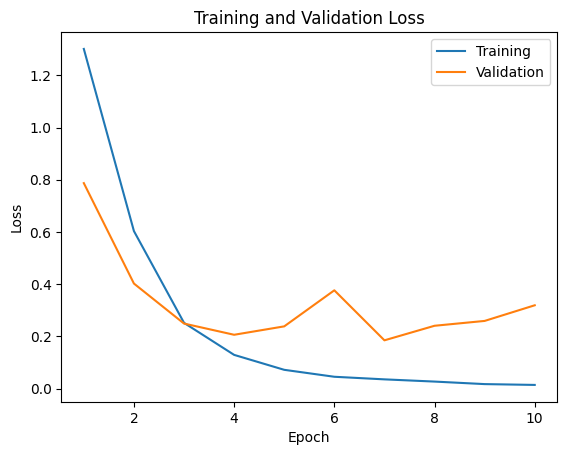

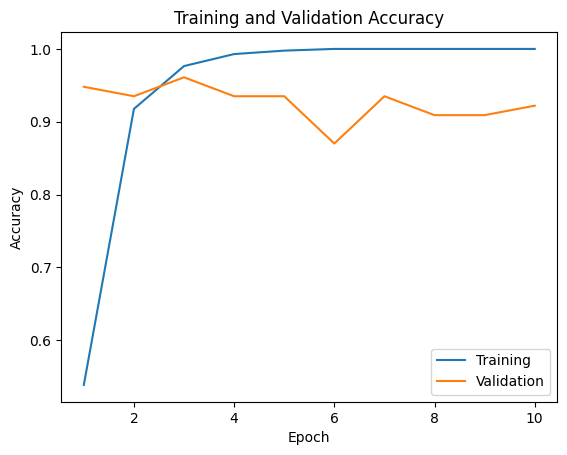

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.922077922077922


In [ ]:
# train the final model
model_final = R2Plus1DModel(num_classes=5)
train(model_final, train_data, val_data, batch_size=16, learning_rate=1e-4, num_epochs=10)

## Test the Final Model

In [ ]:
# test the final model
model_final.eval()
# used to record accuracy per class
num_classes = len(classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes
correct = total = 0
batch_size = 16

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model_final.to(device)

with torch.no_grad():
  for b in range(0, len(test_data), batch_size): # loop through all batches
    batch = test_data[b:b+batch_size] # get the batch section
    videos, labels = load_batch(batch, device) # get the videos and labels from the batch

    output = model_final(videos) # forward pass
    prediction = output.argmax(dim=1) # pick the indices with the largest prediction to be the actual predictions
    correct += (prediction == labels).sum().item() # increment for every image where prediction is same as ground truth
    total += labels.size(0) # increment by size of that batch

    # record accuracy per class
    for i in range(len(labels)):
      label = labels[i].item()
      class_correct[label] += (prediction[i] == labels[i]).item()
      class_total[label] += 1

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")
# print accuracy per class
print("\nAccuracy per Class:")
for i in range(num_classes):
  class_accuracy = class_correct[i] / class_total[i]
  print(f"{classes[i]}: {class_accuracy:.4f}")

# show the confusion matrix
print_confusion_matrix(model_final, test_data, batch_size=16, device=device, classes=classes)

Using device: cuda
Test Accuracy: 0.9891

Accuracy per Class:
BodyWeightSquats: 0.9412
JumpingJack: 1.0000
Lunges: 1.0000
PushUps: 1.0000
WallPushups: 1.0000

Actual \ Predicted  BodyWeightSquats    JumpingJack         Lunges              PushUps             WallPushups         
BodyWeightSquats    16                  0                   1                   0                   0                   
JumpingJack         0                   21                  0                   0                   0                   
Lunges              0                   0                   19                  0                   0                   
PushUps             0                   0                   0                   17                  0                   
WallPushups         0                   0                   0                   0                   18                  


## Prepare Custom Data to Test the Final Model

In [ ]:
from tqdm import tqdm # for progress bar
import subprocess # will be used to resize the custom test videos to 320x240 before frame extraction
custom_test_path = "/content/drive/MyDrive/CustomTestVideos"

# same classes
classes = ["BodyWeightSquats", "JumpingJack", "Lunges", "PushUps", "WallPushups"]
num_classes = len(classes)

video_files = [] # will contain pairs of file path of the video and labels
class_counts = [0] * len(classes) # keep track of the number of videos in each class

# loop through all classes
for class_name in classes:
  class_path = os.path.join(custom_test_path, class_name) # path to the class subfolder
  for file in os.listdir(class_path): # loop through the files
    if file.endswith(".mov"): # all video files are .mov, this is just a safeguard
      video_files.append((os.path.join(class_path, file), class_name)) # add the file path and class label
      class_counts[classes.index(class_name)] += 1 # increment the count for that class

print("Number of Custom Test Videos:", len(video_files))
# print number of videos per class
print("\nVideos per Class:")
for i in range(len(classes)):
  print(f"{classes[i]}: {class_counts[i]}")

# resize videos to 320x240 so extraction is fast
resized_path = "/content/CustomTestVideosResized"
resized_video_files = []  # will replace video_files after resizing

for video_path, label in tqdm(video_files, desc="Resizing videos"):
    # change file extension from .mov to .mp4 for the resized output
    video_name = os.path.basename(video_path).replace('.mov', '.mp4')
    # create the output folder for this class if it doesn't exist
    output_dir = os.path.join(resized_path, label)
    os.makedirs(output_dir, exist_ok=True)
    # full path for the resized output video
    output_path = os.path.join(output_dir, video_name)
    # run ffmpeg to resize the video:
    # -i video_path  : input video
    # scale=320:240  : resize to 320x240 to match UCF101
    # -y             : overwrite output file if it already exists
    # capture_output : suppress ffmpeg's verbose console output
    subprocess.run(['ffmpeg', '-i', video_path, '-vf', 'scale=320:240', '-y', output_path],
                   capture_output=True)
    # store the resized video path with its label
    resized_video_files.append((output_path, label))

# replace original video_files so the rest of the code works unchanged
video_files = resized_video_files

Number of Custom Test Videos: 40

Videos per Class:
BodyWeightSquats: 8
JumpingJack: 8
Lunges: 8
PushUps: 8
WallPushups: 8


Resizing videos: 100%|██████████| 40/40 [04:54<00:00,  7.36s/it]


In [ ]:
def extract_frames_test(video_path, label, num_frames=32):
  video_name = os.path.basename(video_path) # get the video name
  # create the output directory where the frames will go
  frames_dir = "/content/CustomTestFrames"
  output_dir = os.path.join(frames_dir, label, video_name)
  os.makedirs(output_dir, exist_ok=True) # create the directory if it doesn't exist

  # open the video using OpenCV
  video = cv2.VideoCapture(video_path)
  total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT)) # get the total number of frames in the video
  # safety check in case the video failed to open
  if total_frames == 0:
    print("Failed to open video:", video_name)
    return

  # we won't save every frame in the video since there would be quite a lot
  # evenly choose which frames to sample
  frame_indicies = np.linspace(0, total_frames - 1, num_frames, dtype=int)
  frame_indicies = set(frame_indicies) # convert to set for faster lookup
  cur_frame = 0 # keep track of current frame while we loop through the video frames
  saved_frames = 0 # record the number of frames we saved for the video

  # iterate through the video frames until there are no frames left
  while True:
    success, frame = video.read() # read the next frame

    # exit once we reach the end of the video
    if not success:
      break

    # check if the current frame should be saved
    if cur_frame in frame_indicies:

      frame_num = saved_frames
      frame_filename = f"{video_name}_frame_{frame_num:02}.jpg" # set the name for the file
      frame_path = os.path.join(output_dir, frame_filename) # get the file path
      cv2.imwrite(frame_path, frame) # save the frame
      saved_frames += 1 # increment the number of saved frames

    cur_frame += 1 # increment the current frame

  # if we saved fewer than num_frames, repeat the last frame
  while saved_frames < num_frames:
    last_frame_path = os.path.join(output_dir, f"{video_name}_frame_{saved_frames-1:02}.jpg") # previous frame
    new_frame_path = os.path.join(output_dir, f"{video_name}_frame_{saved_frames:02}.jpg") # next frame

    frame = cv2.imread(last_frame_path)
    cv2.imwrite(new_frame_path, frame) # set next frame to be same as previous frame

    saved_frames += 1

  video.release() # release the video

  return saved_frames # return the number of saved frames

In [ ]:
# break the videos into frames (using helper function from above)
total_frames = 0 # keep track of the total number of frames saved
for video_path, label in tqdm(video_files, desc="Converting videos to frames"):
  total_frames += extract_frames_test(video_path, label, num_frames=20)

print(f"\nSaved {total_frames} total frames")

Converting videos to frames: 100%|██████████| 40/40 [02:31<00:00,  3.80s/it]


Saved 800 total frames


In [ ]:
# path to custom test frames
custom_test_path = "/content/CustomTestFrames"

# function to get test folders
def get_custom_test_folders(custom_test_path):
    test_folders = []

    # iterate through each class folder
    for class_name in classes:
        class_path = os.path.join(custom_test_path, class_name)
        if not os.path.exists(class_path):
            continue

        # each subfolder is a video
        for video_name in os.listdir(class_path):
            video_folder_path = os.path.join(class_path, video_name)
            if os.path.isdir(video_folder_path):
                test_folders.append(video_folder_path)

    # shuffle for randomness
    random.seed(1)
    random.shuffle(test_folders)

    print("Total Number of Custom Test Videos:", len(test_folders))
    return test_folders

Total Number of Custom Test Videos: 40
Dimensions of each Frame: 320x240


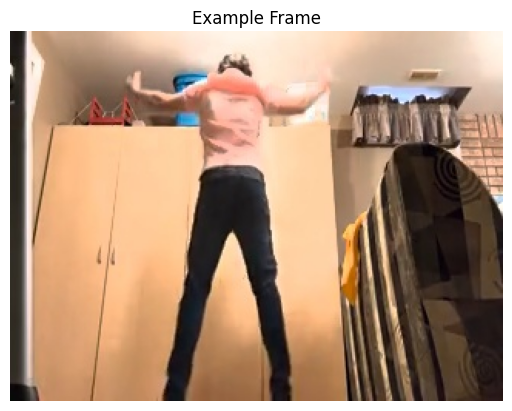

In [ ]:
# get the custom test data
custom_test_folders = get_custom_test_folders(custom_test_path)
custom_test_data = get_data_from_folders(custom_test_folders, num_frames=20)
# shuffle the data
random.seed(1)
random.shuffle(custom_test_data)
# figure out the dimensions of each frame
frame = Image.open(custom_test_data[31][0][6]) # pick any frame
print(f"Dimensions of each Frame: {frame.size[0]}x{frame.size[1]}")
# display an example frame
plt.imshow(frame)
plt.axis("off")
plt.title("Example Frame")
plt.show()
frame.show()

## Test the Final Model on Custom Data
This data has been handcrafted by me and contains videos of myself performing the actions in the 5 classes, so it is guaranteed the model has never seen this data before, even in the pretraining.

In [ ]:
# test the final model
model_final.eval()
# used to record accuracy per class
num_classes = len(classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes
correct = total = 0
batch_size = 16

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model_final.to(device)

with torch.no_grad():
  for b in range(0, len(custom_test_data), batch_size): # loop through all batches
    batch = custom_test_data[b:b+batch_size] # get the batch section
    videos, labels = load_batch(batch, device) # get the videos and labels from the batch

    output = model_final(videos) # forward pass
    prediction = output.argmax(dim=1) # pick the indices with the largest prediction to be the actual predictions
    correct += (prediction == labels).sum().item() # increment for every image where prediction is same as ground truth
    total += labels.size(0) # increment by size of that batch

    # record accuracy per class
    for i in range(len(labels)):
      label = labels[i].item()
      class_correct[label] += (prediction[i] == labels[i]).item()
      class_total[label] += 1

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")
# print accuracy per class
print("\nAccuracy per Class:")
for i in range(num_classes):
  class_accuracy = class_correct[i] / class_total[i]
  print(f"{classes[i]}: {class_accuracy:.4f}")

# show the confusion matrix
print_confusion_matrix(model_final, custom_test_data, batch_size=16, device=device, classes=classes)

Using device: cuda
Test Accuracy: 0.6500

Accuracy per Class:
BodyWeightSquats: 0.5000
JumpingJack: 0.8750
Lunges: 0.0000
PushUps: 0.8750
WallPushups: 1.0000

Actual \ Predicted  BodyWeightSquats    JumpingJack         Lunges              PushUps             WallPushups         
BodyWeightSquats    4                   0                   0                   0                   4                   
JumpingJack         0                   7                   0                   0                   1                   
Lunges              0                   0                   0                   0                   8                   
PushUps             0                   0                   0                   7                   1                   
WallPushups         0                   0                   0                   0                   8                   
